In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from plotsetup import *

# increase fontsizes
plt.rcParams.update({'font.size': 16})

# disable inline backend's auto-cropping so repeated redraws keep a fixed pixel size
get_ipython().run_line_magic('config', "InlineBackend.print_figure_kwargs = {'bbox_inches': None}")


In [9]:
# define a function
f = lambda x: np.exp(-x**2)
df = lambda x: -2 * x * np.exp(-x**2)

In [10]:
def riemann_approximation(f, a, b, n):
    x = np.linspace(a, b, n+1)
    dx = (b - a) / n
    approx = 0
    for i in range(n):
        approx += f(x[i]) * dx
    return approx

In [11]:
very_accurate_integral, abserror = quad(f, a=-2, b=2)
print(very_accurate_integral)
print(abserror)

1.7641627815248433
1.958614141564776e-14


In [12]:
for n in [10, 50, 100, 500, 1000]:
    print(f"n = {n}")
    riemann = riemann_approximation(f, a=-2, b=2, n=n)
    print('Riemann approximation: ', riemann)
    print('Error: ',    very_accurate_integral - riemann)


n = 10
Riemann approximation:  1.7622612252632388
Error:  0.0019015562616044868
n = 50
Riemann approximation:  1.7640847181603483
Error:  7.806336449500684e-05
n = 100
Riemann approximation:  1.7641432500532224
Error:  1.9531471620926055e-05
n = 500
Riemann approximation:  1.7641620000659193
Error:  7.814589240151548e-07
n = 1000
Riemann approximation:  1.7641625861585504
Error:  1.953662929210509e-07


In [13]:
def plot_riemann(f, a, b, n):
    """Plot f on [a, b] together with the left-endpoint Riemann boxes for n subintervals."""
    x = np.linspace(a, b, n + 1)
    dx = (b - a) / n
    heights = f(x[:-1] + dx/2)  # left-endpoint rule, matching riemann_approximation

    x_fine = np.linspace(a, b, 400)

    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(x[:-1], heights, width=dx, align='edge', color='C1', alpha=0.4,
           edgecolor='black', linewidth=0.25, label=f'Riemann boxes (n={n})')
    ax.plot(x_fine, f(x_fine), color='C0', linewidth=2, label='$f(x)$')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$f(x)$')
    #ax.legend()
    ax.set_title(rf'$n = {n}$')
    ax.grid()
    plt.show()



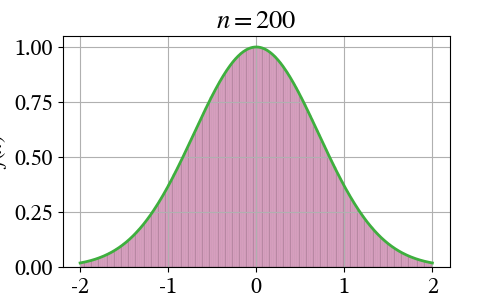

In [16]:

plot_riemann(f, a=-2, b=2, n=200)